# Figure 1: Neural OT rearrangement on the banana target

This notebook trains a neural OT map and a dense rearrangement of that map. The final cell plots only target-space contours: the neural OT pushforward of a latent ball, the rearranged neural OT pushforward of the same ball, and the oracle HDR contour obtained by pushing that ball through the dataset operator.

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import chi2

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent.parent

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.synthetic.sinusoidal_transport import SinusoidalTransportDatasetConfig
from configs.predictors.rearranged_transport.dense import (
    RearrangedTransportPredictorConfig,
)
from configs.predictors.transport import (
    NormalizingFlowPredictorConfig,
    NeuralOptimalTransportPredictorConfig
)
from configs.trainers.rearranged_transport import (
    RearrangedTransportTrainerConfig
)
from configs.trainers.transport import (
    NormalizingFlowTrainerConfig,
    NeuralOptimalTransportTrainerConfig
)
from data.datasets.synthetic.sinusoidal_transport import SinusoidalTransportDataset
from data.loaders import make_xy_dataloader
from predictors.rearranged_transport import RearrangedTransportPredictor
from predictors.transport import NormalizingFlowPredictor, NeuralOptimalTransportPredictor
from trainers.rearranged_transport import RearrangedTransportTrainer
from trainers.transport import NormalizingFlowTrainer, NeuralOptimalTransportTrainer

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [8]:
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

device = "cuda"
dtype = "float32"

n_train = 10_000
n_calibration = 1_024
n_test = 1_024
batch_size = 1_024

coverage_mass = 0.95
x_plot_value = 2.3

ot_epochs = 50
ot_warmup_iterations = 10
c_transform_max_iter = 1000

rearrangement_epochs = 500

n_boundary_points = 720
plot_batch_size = 256

output_path = Path("../figures/figure_1_neural_ot_rearranged.pdf")
output_path.parent.mkdir(parents=True, exist_ok=True)

In [9]:
dataset_config = SinusoidalTransportDatasetConfig(
    n_train=n_train,
    n_calibration=n_calibration,
    n_test=n_test,
    x_dim=1,
    y_dim=2,
    seed=seed,
    device=device,
    dtype=dtype,
)

dataset = SinusoidalTransportDataset(dataset_config)
splits = dataset.get_splits()

train_dataloader = make_xy_dataloader(
    data=splits.train,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

print("train x/y:", splits.train.x.shape, splits.train.y.shape)
print("calibration x/y:", splits.calibration.x.shape, splits.calibration.y.shape)
print("test x/y:", splits.test.x.shape, splits.test.y.shape)

AssertionError: Torch not compiled with CUDA enabled

In [10]:
import torch

torch.cuda.is_available()

False

In [4]:
predictor_config = NeuralOptimalTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dim=64,
    num_hidden_layers=8,
    c_transform_lr=1.,
    c_transform_max_iter=10000,
    seed=seed,
    device=device,
    dtype=dtype,
)

trainer_config = NeuralOptimalTransportTrainerConfig(
    epochs=ot_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    warmup_iterations=ot_warmup_iterations,
    grad_clip_norm=1.0,
    use_cosine_scheduler=True,
    verbose=True,
)

predictor = NeuralOptimalTransportPredictor(predictor_config)
trainer = NeuralOptimalTransportTrainer(trainer_config)

predictor = predictor.load("neural_ot_predictor.pt")

# predictor = trainer.fit(
#     predictor=predictor,
#     dataloader=train_dataloader,
# )
# predictor.eval()

trainer.training_history[-5:]

[]

In [5]:
# predictor.save("normalizing_flow_predictor.pt")

In [6]:
rearranged_predictor_config = RearrangedTransportPredictorConfig(
    x_dim=dataset.x_dim,
    y_dim=dataset.y_dim,
    hidden_dimension=16,
    number_of_hidden_layers=4,
    use_adjoint=False,
    method="euler",
    number_of_steps=8,
    seed=seed,
    device=device,
    dtype=dtype,
)

rearranged_predictor = RearrangedTransportPredictor(
    config=rearranged_predictor_config,
    transport_predictor=predictor,
)

rearranged_trainer_config = RearrangedTransportTrainerConfig(
    epochs=200,
    alpha=coverage_mass,
    train_transport_map=False,
    learning_rate=1e-3,
    weight_decay=1e-4,
    grad_clip_norm=1.0,
    use_cosine_scheduler=True,
    verbose=True,
)

rearranged_trainer = RearrangedTransportTrainer(rearranged_trainer_config)
rearranged_predictor = rearranged_trainer.fit(
    predictor=rearranged_predictor,
    dataloader=train_dataloader,
)
rearranged_predictor.eval()

rearranged_trainer.training_history[-5:]

Epoch 200 | Log-volume 16901362.0000: 100%|██████████| 200/200 [35:19<00:00, 10.60s/it]             


[{'epoch': 196,
  'log_volume_loss': 8909225984.0,
  'radius': 2.447746830680816,
  'alpha': 0.95,
  'mc_samples_per_x': 1,
  'training_time': 10.53672483295668,
  'learning_rate': 9.866357858642221e-07},
 {'epoch': 197,
  'log_volume_loss': 147181764608.0,
  'radius': 2.447746830680816,
  'alpha': 0.95,
  'mc_samples_per_x': 1,
  'training_time': 10.550208416068926,
  'learning_rate': 5.550625190150488e-07},
 {'epoch': 198,
  'log_volume_loss': 541365.75,
  'radius': 2.447746830680816,
  'alpha': 0.95,
  'mc_samples_per_x': 1,
  'training_time': 10.514835999929346,
  'learning_rate': 2.4671981713420014e-07},
 {'epoch': 199,
  'log_volume_loss': 339443.96875,
  'radius': 2.447746830680816,
  'alpha': 0.95,
  'mc_samples_per_x': 1,
  'training_time': 10.581977916997857,
  'learning_rate': 6.168375916970624e-08},
 {'epoch': 200,
  'log_volume_loss': 16901362.0,
  'radius': 2.447746830680816,
  'alpha': 0.95,
  'mc_samples_per_x': 1,
  'training_time': 10.541837458033115,
  'learning_rate

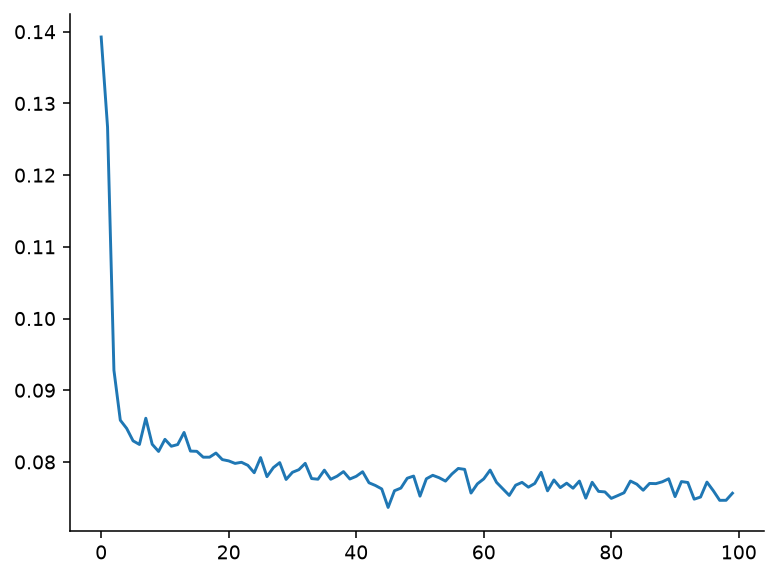

In [30]:
plt.plot([epoch['log_volume_loss'] for epoch in rearranged_trainer.training_history])

In [31]:
def circle_boundary(radius, n_points):
    theta = np.linspace(0.0, 2.0 * np.pi, n_points, endpoint=False)
    boundary = np.column_stack([np.cos(theta), np.sin(theta)]) * radius
    return torch.as_tensor(boundary, device=dataset.device, dtype=dataset.dtype)


def close_contour(contour):
    contour = np.asarray(contour)
    if np.allclose(contour[0], contour[-1]):
        return contour
    return np.vstack([contour, contour[0]])


def repeated_x(batch_size, x_value=0.):
    return torch.full(
        (batch_size, dataset.x_dim),
        fill_value=x_value,
        device=dataset.device,
        dtype=dataset.dtype,
    )


def model_pushforward_contour(model, u, batch_size=plot_batch_size):
    mapped = []
    for start in range(0, u.shape[0], batch_size):
        u_batch = u[start:start + batch_size]
        x_batch = repeated_x(u_batch.shape[0]).to(u_batch)
        y_batch = model.pushforward(x=x_batch, u=u_batch)
        mapped.append(y_batch.detach().cpu())
    return close_contour(torch.cat(mapped, dim=0).numpy())


def oracle_pushforward_contour(u, batch_size=plot_batch_size):
    mapped = []
    for start in range(0, u.shape[0], batch_size):
        u_batch = u[start:start + batch_size]
        x_batch = repeated_x(u_batch.shape[0]).to(u_batch)
        y_batch = dataset.push_u_given_x(u=u_batch, x=x_batch)
        mapped.append(y_batch.detach().cpu())
    return close_contour(torch.cat(mapped, dim=0).numpy())


def contour_bounds(contours, side_margin=0.05, bottom_margin=0.10, top_margin=0.20):
    points = np.vstack([np.asarray(contour) for contour in contours])
    xmin, ymin = points.min(axis=0)
    xmax, ymax = points.max(axis=0)
    width = max(xmax - xmin, 1e-12)
    height = max(ymax - ymin, 1e-12)
    return (
        xmin - side_margin * width,
        xmax + side_margin * width,
        ymin - bottom_margin * height,
        ymax + top_margin * height,
    )

coverage_mass = 0.950
x = 2.300
source radius = 2.4477


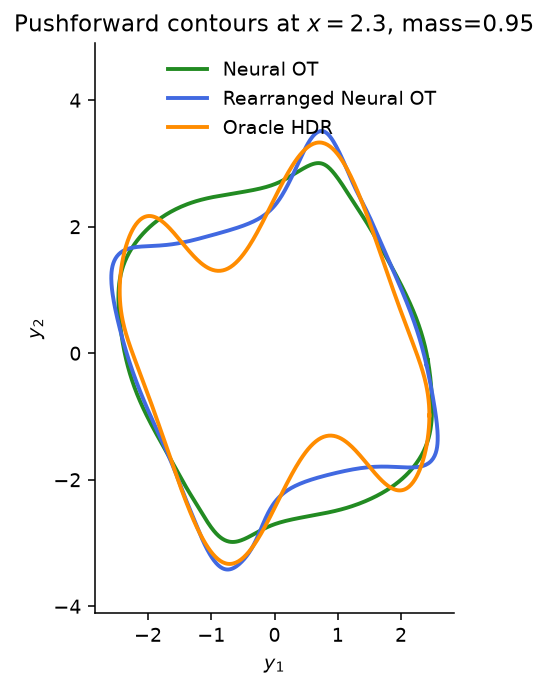

In [32]:
plotting_coverage_mass = 0.95

r_source = float(np.sqrt(chi2.ppf(plotting_coverage_mass, df=dataset.y_dim)))
source_ball_boundary = circle_boundary(
    radius=r_source,
    n_points=n_boundary_points,
)

neural_ot_contour = model_pushforward_contour(predictor, source_ball_boundary)
rearranged_contour = model_pushforward_contour(
    rearranged_predictor,
    source_ball_boundary,
)
oracle_hdr_contour = oracle_pushforward_contour(source_ball_boundary)

xmin, xmax, ymin, ymax = contour_bounds([
    neural_ot_contour,
    rearranged_contour,
    oracle_hdr_contour,
])

print(f"coverage_mass = {plotting_coverage_mass:.3f}")
print(f"x = {x_plot_value:.3f}")
print(f"source radius = {r_source:.4f}")

fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)

ax.plot(
    neural_ot_contour[:, 0],
    neural_ot_contour[:, 1],
    color="forestgreen",
    linewidth=2.0,
    label="Neural OT",
)
ax.plot(
    rearranged_contour[:, 0],
    rearranged_contour[:, 1],
    color="royalblue",
    linewidth=2.0,
    label="Rearranged Neural OT",
)
ax.plot(
    oracle_hdr_contour[:, 0],
    oracle_hdr_contour[:, 1],
    color="darkorange",
    linewidth=2.0,
    label="Oracle HDR",
)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$y_1$")
ax.set_ylabel(r"$y_2$")
ax.set_title(
    rf"Pushforward contours at $x={x_plot_value:.1f}$, mass={coverage_mass:.2f}"
)
ax.legend(frameon=False, loc="upper right")

fig.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    metadata={"Creator": "Matplotlib"},
)

plt.show()

In [20]:
predictor.save("neural_ot_predictor")

In [17]:
u = torch.randn(1024, 2)
x = torch.zeros(1024, 1)
u_np = u.detach().numpy()
u_pf_np =  rearranged_predictor.rearrangement_flow.forward(
    u=u,
    x=x,
    end_time=1.
).detach().numpy()


x = torch.zeros(source_ball_boundary.shape[0], 1)

scale_to_pf_boundary = {}
scale_to_sc_boundary = {}
for scale in [1., 2., 3., 4., 5., 6., 7., 8.]:
    scale /= 7.
    scaled_source_boundary = source_ball_boundary * scale
    scale_to_sc_boundary[scale] = scaled_source_boundary.numpy()
    scale_to_pf_boundary[scale] = rearranged_predictor.rearrangement_flow.forward(
        u=scaled_source_boundary,
        x=x,
        end_time=1.
    ).detach().numpy()
    

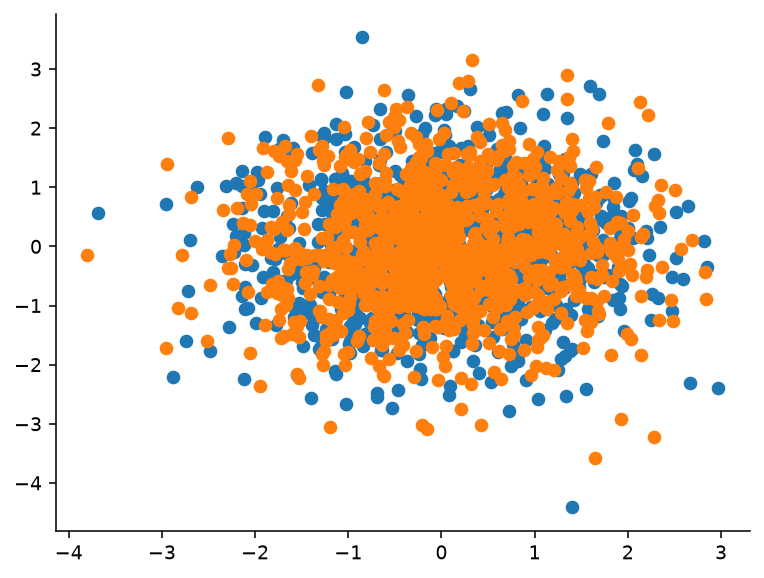

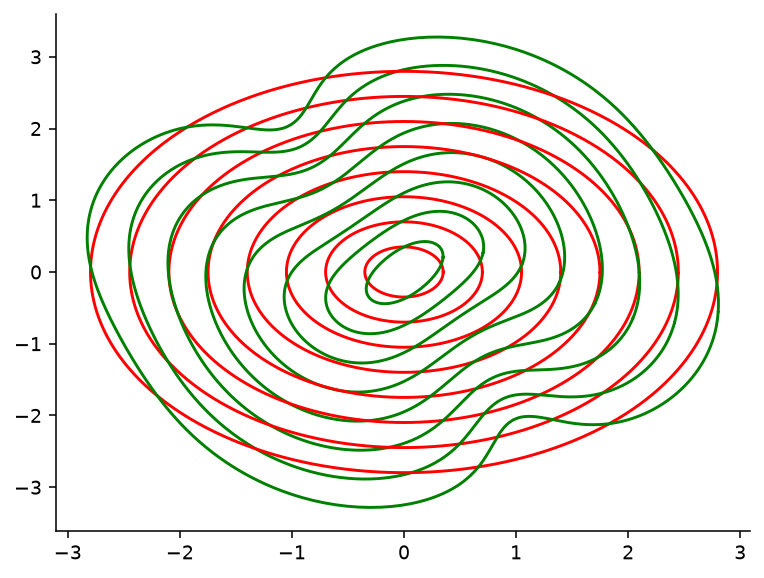

In [18]:
plt.scatter(u_np[:, 0], u_np[:, 1])
plt.scatter(u_pf_np[:, 0], u_pf_np[:, 1])
plt.show()

for scale in scale_to_sc_boundary.keys():

    plt.plot(scale_to_sc_boundary[scale][:, 0], scale_to_sc_boundary[scale][:, 1], c="red")
    plt.plot(scale_to_pf_boundary[scale][:, 0], scale_to_pf_boundary[scale][:, 1], c='green')
    
plt.show()